In [49]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

In [50]:
df = pd.read_csv(r'spam.csv', encoding='latin-1')
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


## Preprocessing

In [51]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [52]:
df.duplicated().sum()

np.int64(403)

In [53]:
df.drop_duplicates(keep='first', inplace=True)

In [54]:
df.shape

(5169, 2)

In [55]:
df.rename(columns={'v1':'target', 'v2':'message'}, inplace=True)

In [56]:
df

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [57]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\garvc\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [58]:
df['characters_length'] = df['message'].apply(lambda x: len(x))
df

,target,message,characters_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [59]:
df['words_length'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))
df

,target,message,characters_length,words_length
0,ham,"Go until jurong point, crazy.. Available only ...",111,24
1,ham,Ok lar... Joking wif u oni...,29,8
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,ham,U dun say so early hor... U c already then say...,49,13
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35
5568,ham,Will Ì_ b going to esplanade fr home?,37,9
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15
5570,ham,The guy did some bitching but I acted like i'd...,125,27


In [60]:
df['sentence_length'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))
df

,target,message,characters_length,words_length,sentence_length
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,ham,Will Ì_ b going to esplanade fr home?,37,9,1
5569,ham,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,ham,The guy did some bitching but I acted like i'd...,125,27,1


In [61]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])

In [62]:
# 0 -> Not spam, 1 -> Spam
df

,target,message,characters_length,words_length,sentence_length
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


## EDA

In [63]:
ratio_df = df['target'].value_counts().reset_index()

In [64]:
ratio_df['target'] = ratio_df['target'].map({0 : 'Not Spam', 1 : 'Spam'})

In [65]:
ratio_df['percentage'] = round(ratio_df['count'] / ratio_df['count'].sum() * 100, 2)

In [66]:
ratio_df

,target,count,percentage
0,Not Spam,4516,87.37
1,Spam,653,12.63


In [67]:
px.bar(ratio_df, x='target', y='count', color='target', text='percentage')

In [68]:
df.groupby('target').describe().T

target                             0           1
characters_length count  4516.000000  653.000000
                  mean     70.459256  137.891271
                  std      56.358207   30.137753
                  min       2.000000   13.000000
                  25%      34.000000  132.000000
                  50%      52.000000  149.000000
                  75%      90.000000  157.000000
                  max     910.000000  224.000000
words_length      count  4516.000000  653.000000
                  mean     17.123782   27.667688
                  std      13.493970    7.008418
                  min       1.000000    2.000000
                  25%       8.000000   25.000000
                  50%      13.000000   29.000000
                  75%      22.000000   32.000000
                  max     220.000000   46.000000
sentence_length   count  4516.000000  653.000000
                  mean      1.820195    2.970904
                  std       1.383657    1.488425
                  min       1.000000    1.000000
                  25%       1.000000    2.000000
                  50%       1.000000    3.000000
                  75%       2.000000    4.000000
                  max      38.000000    9.000000

In [69]:
px.histogram(df,x='characters_length', color='target', barmode='overlay', opacity=0.7)

In [70]:
px.histogram(df,x='words_length', color='target', barmode='overlay', opacity=0.7)

<Axes: >

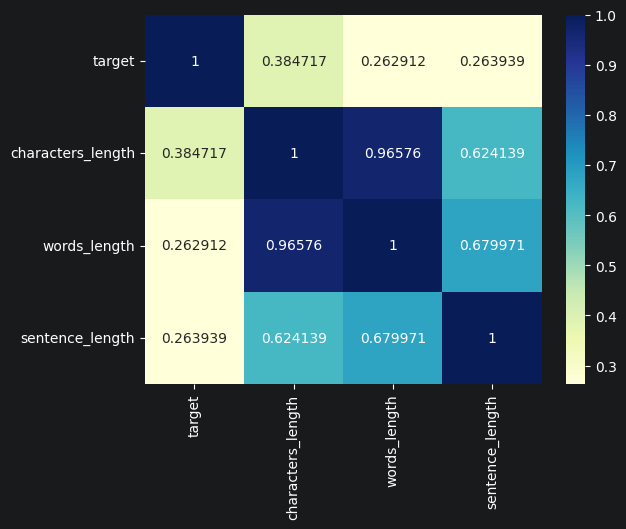

In [71]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='g', cmap='YlGnBu')

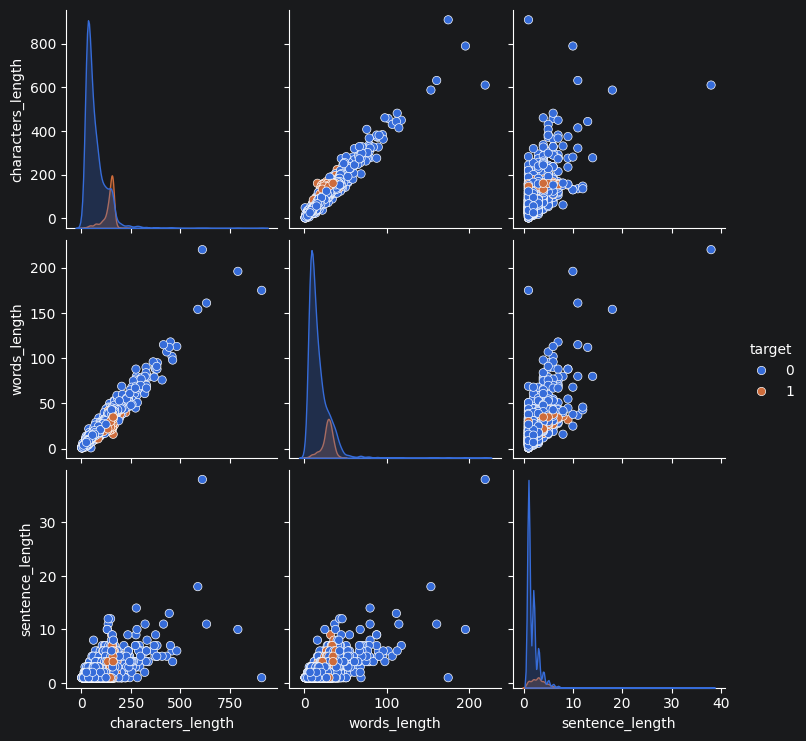

In [72]:
sns.pairplot(df, hue='target')

## Data/Text Preprocessing

In [73]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [74]:
from nltk.corpus import stopwords

In [75]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\garvc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [76]:
from nltk.stem.porter import PorterStemmer

In [77]:
def preprocess(text):
    text = text.lower()

    text = nltk.word_tokenize(text)
    text = [word for word in text if word.isalpha()]
    text = [word for word in text if not word in string.punctuation]
    text = [word for word in text if not word in stopwords.words('english')]

    ps = PorterStemmer()
    text = [ps.stem(word) for word in text]

    return ' '.join(text)

In [78]:
preprocess('Hi! How are you my darling??')

'hi darl'

In [79]:
transformed_text = df['message'].apply(preprocess)
df.insert(1, 'transformed_text', transformed_text)

In [80]:
df

,target,transformed_text,message,characters_length,words_length,sentence_length
0,0,go jurong point crazi avail bugi n great world...,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,ok lar joke wif u oni,Ok lar... Joking wif u oni...,29,8,2
2,1,free entri wkli comp win fa cup final tkt may ...,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,u dun say earli hor u c alreadi say,U dun say so early hor... U c already then say...,49,13,1
4,0,nah think goe usf live around though,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...,...
5567,1,time tri contact u pound prize claim easi call...,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,b go esplanad fr home,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,piti mood suggest,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,guy bitch act like interest buy someth els nex...,The guy did some bitching but I acted like i'd...,125,27,1


In [81]:
from wordcloud import WordCloud
wc = WordCloud(height=500, width=500, min_font_size=10, background_color='white')

In [82]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))

In [83]:
px.imshow(spam_wc)

In [84]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))
px.imshow(ham_wc)

In [85]:
all_words = []

for mssg in df[df['target'] == 1]['transformed_text'].to_list():
    for wrd in mssg.split():
        all_words.append(wrd)

all_words

['free',
 'entri',
 'wkli',
 'comp',
 'win',
 'fa',
 'cup',
 'final',
 'tkt',
 'may',
 'text',
 'fa',
 'receiv',
 'entri',
 'question',
 'std',
 'txt',
 'rate',
 'c',
 'appli',
 'freemsg',
 'hey',
 'darl',
 'week',
 'word',
 'back',
 'like',
 'fun',
 'still',
 'tb',
 'ok',
 'xxx',
 'std',
 'chg',
 'send',
 'rcv',
 'winner',
 'valu',
 'network',
 'custom',
 'select',
 'receivea',
 'prize',
 'reward',
 'claim',
 'call',
 'claim',
 'code',
 'valid',
 'hour',
 'mobil',
 'month',
 'u',
 'r',
 'entitl',
 'updat',
 'latest',
 'colour',
 'mobil',
 'camera',
 'free',
 'call',
 'mobil',
 'updat',
 'co',
 'free',
 'six',
 'chanc',
 'win',
 'cash',
 'pound',
 'txt',
 'send',
 'cost',
 'tsandc',
 'appli',
 'repli',
 'hl',
 'info',
 'urgent',
 'week',
 'free',
 'membership',
 'prize',
 'jackpot',
 'txt',
 'word',
 'claim',
 'c',
 'lccltd',
 'pobox',
 'xxxmobilemovieclub',
 'use',
 'credit',
 'click',
 'wap',
 'link',
 'next',
 'txt',
 'messag',
 'click',
 'http',
 'england',
 'v',
 'macedonia',
 'do

In [86]:
from collections import Counter
spam_freq_wrds = pd.DataFrame(Counter(all_words).most_common(30)).rename(columns={0:'word', 1:'count'})

In [87]:
px.bar(spam_freq_wrds, x='word', y='count', color='word', text='count')

In [88]:
all_words = []

for mssg in df[df['target'] == 0]['transformed_text'].to_list():
    for wrd in mssg.split():
        all_words.append(wrd)

all_words

['go',
 'jurong',
 'point',
 'crazi',
 'avail',
 'bugi',
 'n',
 'great',
 'world',
 'la',
 'e',
 'buffet',
 'cine',
 'got',
 'amor',
 'wat',
 'ok',
 'lar',
 'joke',
 'wif',
 'u',
 'oni',
 'u',
 'dun',
 'say',
 'earli',
 'hor',
 'u',
 'c',
 'alreadi',
 'say',
 'nah',
 'think',
 'goe',
 'usf',
 'live',
 'around',
 'though',
 'even',
 'brother',
 'like',
 'speak',
 'treat',
 'like',
 'aid',
 'patent',
 'per',
 'request',
 'mell',
 'oru',
 'minnaminungint',
 'nurungu',
 'vettam',
 'set',
 'callertun',
 'caller',
 'press',
 'copi',
 'friend',
 'callertun',
 'gon',
 'na',
 'home',
 'soon',
 'want',
 'talk',
 'stuff',
 'anymor',
 'tonight',
 'k',
 'cri',
 'enough',
 'today',
 'search',
 'right',
 'word',
 'thank',
 'breather',
 'promis',
 'wont',
 'take',
 'help',
 'grant',
 'fulfil',
 'promis',
 'wonder',
 'bless',
 'time',
 'date',
 'sunday',
 'oh',
 'k',
 'watch',
 'eh',
 'u',
 'rememb',
 'spell',
 'name',
 'ye',
 'v',
 'naughti',
 'make',
 'v',
 'wet',
 'fine',
 'thatåõ',
 'way',
 'u',
 '

In [89]:
ham_freq_wrds = pd.DataFrame(Counter(all_words).most_common(30)).rename(columns={0:'word', 1:'count'})

In [90]:
px.bar(ham_freq_wrds, x='word', y='count', color='word', text='count')

## Model Building

In [91]:
df

,target,transformed_text,message,characters_length,words_length,sentence_length
0,0,go jurong point crazi avail bugi n great world...,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,ok lar joke wif u oni,Ok lar... Joking wif u oni...,29,8,2
2,1,free entri wkli comp win fa cup final tkt may ...,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,u dun say earli hor u c alreadi say,U dun say so early hor... U c already then say...,49,13,1
4,0,nah think goe usf live around though,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...,...
5567,1,time tri contact u pound prize claim easi call...,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,b go esplanad fr home,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,piti mood suggest,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,guy bitch act like interest buy someth els nex...,The guy did some bitching but I acted like i'd...,125,27,1


In [102]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [103]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [112]:
X.shape

(5169, 5849)

In [105]:
y = df['target']

In [106]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [107]:
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, classification_report

In [110]:
y_train.value_counts()

target
0    3627
1     508
Name: count, dtype: int64

In [111]:
y_test.value_counts()

target
0    889
1    145
Name: count, dtype: int64

In [131]:
bnb = BernoulliNB(class_prior=[0.95,0.05])
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
acc_scores.append(accuracy_score(y_test, y_pred))
prec_scores.append(precision_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9642166344294004
0.9655172413793104
[[885   4]
 [ 33 112]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       0.97      0.77      0.86       145

    accuracy                           0.96      1034
   macro avg       0.96      0.88      0.92      1034
weighted avg       0.96      0.96      0.96      1034



In [121]:
bnb.predict_proba(X_test)[:,1]

array([1.07523821e-05, 9.99998796e-01, 8.29835606e-09, ...,
       9.99999978e-01, 2.00714483e-09, 8.24561446e-09], shape=(1034,))

In [132]:
mnb = MultinomialNB(class_prior=[0.95,0.05])
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
acc_scores.append(accuracy_score(y_test, y_pred))
prec_scores.append(precision_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9758220502901354
0.9166666666666666
[[877  12]
 [ 13 132]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       889
           1       0.92      0.91      0.91       145

    accuracy                           0.98      1034
   macro avg       0.95      0.95      0.95      1034
weighted avg       0.98      0.98      0.98      1034



In [135]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [136]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [137]:
X.shape

(5169, 5849)

In [138]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [139]:
bnb = BernoulliNB(class_prior=[0.95,0.05])
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
acc_scores.append(accuracy_score(y_test, y_pred))
prec_scores.append(precision_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9642166344294004
0.9655172413793104
[[885   4]
 [ 33 112]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       0.97      0.77      0.86       145

    accuracy                           0.96      1034
   macro avg       0.96      0.88      0.92      1034
weighted avg       0.96      0.96      0.96      1034



In [140]:
mnb = MultinomialNB(class_prior=[0.95,0.05])
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
acc_scores.append(accuracy_score(y_test, y_pred))
prec_scores.append(precision_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9352030947775629
1.0
[[889   0]
 [ 67  78]]
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       889
           1       1.00      0.54      0.70       145

    accuracy                           0.94      1034
   macro avg       0.96      0.77      0.83      1034
weighted avg       0.94      0.94      0.93      1034



In [143]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [148]:
svc = SVC(kernel='sigmoid', gamma='auto')
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
mnb = MultinomialNB(class_prior=[0.95,0.05])
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
lrc = LogisticRegression(solver='liblinear',  l1_ratio=0 ,random_state=42, n_jobs=-1)
abc = AdaBoostClassifier(n_estimators=100, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gdbt = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgbt = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [149]:
classifiers = {
    'SVM' : svc,
    'KNN' : knc,
    'RF' : rfc,
    'MultinomialNB' : mnb,
    'DecisionTreeClassifier' : dtc,
    'LogisticRegression' : lrc,
    'AdaBoostClassifier' : abc,
    'BaggingClassifier' : bc,
    'ExtraTreesClassifier' : etc,
    'GradientBoostingClassifier' : gdbt,
    'XGBClassifier' : xgbt,
}

In [150]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    ac_score = accuracy_score(y_test, y_pred)
    prc_score = precision_score(y_test, y_pred)
    print('Accuracy Score: ', ac_score)
    print('Precision Score: ', prc_score)

    return ac_score, prc_score

In [151]:
acc_scores = []
prec_scores = []
for name, clf in classifiers.items():
    print('Name :', name)
    ac_score, prc_score = train_classifier(clf, X_train, y_train, X_test, y_test)
    print()

    acc_scores.append(ac_score)
    prec_scores.append(prc_score)

Name : SVM


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Accuracy Score:  0.8597678916827853
Precision Score:  0.0

Name : KNN
Accuracy Score:  0.9216634429400387
Precision Score:  1.0

Name : RF
Accuracy Score:  0.9690522243713733
Precision Score:  1.0

Name : MultinomialNB
Accuracy Score:  0.9352030947775629
Precision Score:  1.0

Name : DecisionTreeClassifier
Accuracy Score:  0.9332688588007737
Precision Score:  0.8015873015873016

Name : LogisticRegression
Accuracy Score:  0.9506769825918762
Precision Score:  0.9433962264150944

Name : AdaBoostClassifier


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.



Accuracy Score:  0.9197292069632496
Precision Score:  0.7924528301886793

Name : BaggingClassifier
Accuracy Score:  0.9622823984526112
Precision Score:  0.8732394366197183

Name : ExtraTreesClassifier
Accuracy Score:  0.9758220502901354
Precision Score:  1.0

Name : GradientBoostingClassifier
Accuracy Score:  0.9564796905222437
Precision Score:  0.9464285714285714

Name : XGBClassifier
Accuracy Score:  0.971953578336557
Precision Score:  0.9461538461538461



In [155]:
performance_df = pd.DataFrame({'models' : classifiers.keys(), 'accuracy' : acc_scores, 'precision' : prec_scores})

In [156]:
performance_df.sort_values(['precision', 'accuracy'], ascending=[False, False])

,models,accuracy,precision
8,ExtraTreesClassifier,0.975822,1.000000
2,RF,0.969052,1.000000
3,MultinomialNB,0.935203,1.000000
1,KNN,0.921663,1.000000
9,GradientBoostingClassifier,0.956480,0.946429
10,XGBClassifier,0.971954,0.946154
5,LogisticRegression,0.950677,0.943396
7,BaggingClassifier,0.962282,0.873239
4,DecisionTreeClassifier,0.933269,0.801587
6,AdaBoostClassifier,0.919729,0.792453


In [158]:
px.bar(performance_df, x='models', y=['accuracy', 'precision'], barmode='group', title='Accuracy vs Precision')

In [159]:
# Voting Classifier
from sklearn.ensemble import VotingClassifier

rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
mnb = MultinomialNB(class_prior=[0.95,0.05])
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)

voting = VotingClassifier(estimators=[('nb', mnb), ('et', etc), ('rf', rfc)], voting='soft')

In [160]:
voting.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('nb', ...), ('et', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.","[0.95, 0.05]"
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100


In [161]:
y_pred = voting.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.9642166344294004
1.0
[[889   0]
 [ 37 108]]


In [162]:
# Applying Stacking
from sklearn.ensemble import StackingClassifier

clf = StackingClassifier(estimators=[('nb', mnb), ('et', etc), ('rf', rfc)],final_estimator=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), n_jobs=-1)

In [163]:
clf.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('nb', ...), ('et', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",RandomForestC...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data."

In [164]:
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.97678916827853
0.9416058394160584
[[881   8]
 [ 16 129]]


## Limiting Max features in TFIDF

In [165]:
tfidf = TfidfVectorizer(max_features=3000)

In [166]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [167]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [168]:
svc = SVC(kernel='sigmoid', gamma='auto')
knc = KNeighborsClassifier()
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
mnb = MultinomialNB(class_prior=[0.95,0.05])
dtc = DecisionTreeClassifier(max_depth=5, random_state=42)
lrc = LogisticRegression(solver='liblinear',  l1_ratio=0 ,random_state=42, n_jobs=-1)
abc = AdaBoostClassifier(n_estimators=100, random_state=42)
bc = BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1)
etc = ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)
gdbt = GradientBoostingClassifier(n_estimators=100, random_state=42)
xgbt = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [169]:
classifiers = {
    'SVM' : svc,
    'KNN' : knc,
    'RF' : rfc,
    'MultinomialNB' : mnb,
    'DecisionTreeClassifier' : dtc,
    'LogisticRegression' : lrc,
    'AdaBoostClassifier' : abc,
    'BaggingClassifier' : bc,
    'ExtraTreesClassifier' : etc,
    'GradientBoostingClassifier' : gdbt,
    'XGBClassifier' : xgbt,
}

In [172]:
from sklearn.metrics import recall_score

In [170]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    ac_score = accuracy_score(y_test, y_pred)
    prc_score = precision_score(y_test, y_pred)
    rec_score = recall_score(y_test, y_pred)
    print('Accuracy Score: ', ac_score)
    print('Precision Score: ', prc_score)
    print('Recall Score: ', rec_score)

    return ac_score, prc_score, rec_score

In [173]:
acc_scores = []
prec_scores = []
rec_scores = []
for name, clf in classifiers.items():
    print('Name :', name)
    ac_score, prc_score, rc_score = train_classifier(clf, X_train, y_train, X_test, y_test)
    print()

    acc_scores.append(ac_score)
    prec_scores.append(prc_score)
    rec_scores.append(rc_score)

Name : SVM


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Accuracy Score:  0.8597678916827853
Precision Score:  0.0
Recall Score:  0.0

Name : KNN
Accuracy Score:  0.9197292069632496
Precision Score:  1.0
Recall Score:  0.42758620689655175

Name : RF
Accuracy Score:  0.9680851063829787
Precision Score:  0.9912280701754386
Recall Score:  0.7793103448275862

Name : MultinomialNB
Accuracy Score:  0.9555125725338491
Precision Score:  1.0
Recall Score:  0.6827586206896552

Name : DecisionTreeClassifier
Accuracy Score:  0.9323017408123792
Precision Score:  0.8260869565217391
Recall Score:  0.6551724137931034

Name : LogisticRegression
Accuracy Score:  0.9555125725338491
Precision Score:  0.9459459459459459
Recall Score:  0.7241379310344828

Name : AdaBoostClassifier


C:\Users\garvc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning:

'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.



Accuracy Score:  0.9187620889748549
Precision Score:  0.8144329896907216
Recall Score:  0.5448275862068965

Name : BaggingClassifier
Accuracy Score:  0.960348162475822
Precision Score:  0.8714285714285714
Recall Score:  0.8413793103448276

Name : ExtraTreesClassifier
Accuracy Score:  0.9758220502901354
Precision Score:  0.9761904761904762
Recall Score:  0.8482758620689655

Name : GradientBoostingClassifier
Accuracy Score:  0.9593810444874274
Precision Score:  0.9557522123893806
Recall Score:  0.7448275862068966

Name : XGBClassifier
Accuracy Score:  0.9709864603481625
Precision Score:  0.96
Recall Score:  0.8275862068965517



In [175]:
performance_df['acc_after_limiting_feat'] = acc_scores
performance_df['prec_after_limiting_feat'] = prec_scores
performance_df['rec_after_limiting_feat'] = rec_scores

In [176]:
performance_df

,models,accuracy,precision,acc_after_limiting_feat,prec_after_limiting_feat,rec_after_limiting_feat
0,SVM,0.859768,0.000000,0.859768,0.000000,0.000000
1,KNN,0.921663,1.000000,0.919729,1.000000,0.427586
2,RF,0.969052,1.000000,0.968085,0.991228,0.779310
3,MultinomialNB,0.935203,1.000000,0.955513,1.000000,0.682759
4,DecisionTreeClassifier,0.933269,0.801587,0.932302,0.826087,0.655172
5,LogisticRegression,0.950677,0.943396,0.955513,0.945946,0.724138
6,AdaBoostClassifier,0.919729,0.792453,0.918762,0.814433,0.544828
7,BaggingClassifier,0.962282,0.873239,0.960348,0.871429,0.841379
8,ExtraTreesClassifier,0.975822,1.000000,0.975822,0.976190,0.848276
9,GradientBoostingClassifier,0.956480,0.946429,0.959381,0.955752,0.744828
